# SSP2-4.5 vs SSP5-8.5 Divergence Study -- Larissa (2026-2100)

Larissa counterpart of `SSP_Divergence_Study_Seville.ipynb` -- same motivating question (at what
point, if any, does a single-realization SSP2-4.5 vs SSP5-8.5 comparison stop being dominated by
internal-variability noise), same extended 2026-2100 `cmcc_esm2` pulls, same Equidistant CDF
Matching bias correction against ERA5. See
`documentation/SSP_Scenario_Uncertainty_Interpretation.md` for the full reasoning and literature
sources (Hawkins & Sutton 2009, O'Neill et al. 2021), and the Seville notebook for the general
approach -- not repeated here.

**Indicators, adapted to Larissa's own headline set** (matching `larissa_cmip6_projection_eda.ipynb`,
not Seville's heat/fire framing): `tmin_mean` (chronic nighttime warming), `precip_total`, and
`max_week_precip_mm` (flood-peak intensity) -- Larissa's story is precipitation volatility, not heat,
so those are the indicators worth testing for scenario divergence here.

**Source data:** both scenarios' raw pulls were extended to 2026-2100 the same way as Seville's
(`scripts/extend_cmip6_projections_ssp245_2046_2100.py`,
`scripts/extend_cmip6_projections_ssp585_2062_2100.py` -- both already loop over Larissa alongside
Seville), then bias-corrected via `scripts/bias_correct_divergence_study_larissa.py`.

**What this notebook does NOT do:** rebuild the full indicator suite (heatwaves, wet-day stats)
for the extended window -- out of scope for this focused comparison, same as the Seville version.
`min_spi3` and three additional wet-side indicators (`rx1day_mm`, heavy-day count, SDII) are
included via standalone scripts (`scripts/compute_divergence_spi3.py`,
`scripts/compute_divergence_larissa_wet_indicators.py`) rather than a full notebook rebuild.

**Note on what actually motivated the extension to 2100:** not a check of "was 2061 far enough" --
the real trigger, found while extending, was that `tmin_mean`'s divergence signal starts building
*immediately after* the original notebooks' own 2026-2045 window. Section 10 below shows this
directly, mirroring the same finding in the Seville notebook.

**Standing caveat:** single model (`cmcc_esm2`), single realization (`r1i1p1f1`) per scenario for
Larissa too -- confirmed via the same CDS/ESGF check as Seville. Everything below characterizes this
one pair of simulations, not a calibrated forecast.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

pd.set_option("display.width", 140)

SSP245_CSV = Path("../SSP2-4.5/data/larissa_cmip6_cmcc_esm2_ssp245_2026_2100_biascorrected.csv")
SSP585_CSV = Path("../SSP5-8.5/data/larissa_cmip6_cmcc_esm2_ssp585_2026_2100_biascorrected.csv")
ERA5_ANNUAL_CSV = Path("../../Historical/eda_outputs/larissa/annual_summary.csv")
ERA5_INDICATORS_CSV = Path("../../Historical/eda_outputs/larissa/larissa_climate_indicators_annual.csv")
FIG_DIR = Path("../figures")
OUT_DIR = Path("../eda_outputs")
FIG_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

print("SSP2-4.5 file exists:", SSP245_CSV.exists())
print("SSP5-8.5 file exists:", SSP585_CSV.exists())
print("ERA5 annual file exists:", ERA5_ANNUAL_CSV.exists())
print("ERA5 indicators file exists:", ERA5_INDICATORS_CSV.exists())

SSP2-4.5 file exists: True
SSP5-8.5 file exists: True
ERA5 annual file exists: True
ERA5 indicators file exists: True


## 2. Load both scenarios and build annual summaries

`max_week_precip_mm` uses the identical construction as `larissa_cmip6_projection_eda.ipynb`
Section 8/14: a weekly-resampled sum of daily precipitation, then the annual max of those weekly
sums, labeled by the calendar year the week falls in.

In [2]:
ssp245_daily = pd.read_csv(SSP245_CSV, index_col=0, parse_dates=True)
ssp585_daily = pd.read_csv(SSP585_CSV, index_col=0, parse_dates=True)
era5_annual = pd.read_csv(ERA5_ANNUAL_CSV, index_col="year")
era5_indicators = pd.read_csv(ERA5_INDICATORS_CSV, index_col="year")

def annual_max_week_precip(frame, precip_col="precip_mm_day"):
    weekly = frame[precip_col].resample("W").sum()
    weekly_year = weekly.index.to_series().apply(lambda ts: ts.year)
    return weekly.groupby(weekly_year).max().rename("max_week_precip_mm").rename_axis("year")

def annual_summary(daily):
    ann = pd.DataFrame({
        "tmin_mean": daily.groupby("year")["tmin_c"].mean(),
        "tmax_mean": daily.groupby("year")["tmax_c"].mean(),
        "precip_total": daily.groupby("year")["precip_mm_day"].sum(),
    })
    ann = ann.join(annual_max_week_precip(daily), how="left")
    return ann

ann245 = annual_summary(ssp245_daily)
ann585 = annual_summary(ssp585_daily)

print(f"SSP2-4.5: {len(ann245)} years, {ann245.index.min()}-{ann245.index.max()}")
print(f"SSP5-8.5: {len(ann585)} years, {ann585.index.min()}-{ann585.index.max()}")
ann245.describe().round(2)

SSP2-4.5: 75 years, 2026-2100
SSP5-8.5: 75 years, 2026-2100


,tmin_mean,tmax_mean,precip_total,max_week_precip_mm
count,75.00,75.00,75.00,75.00
mean,14.49,24.39,522.15,74.87
std,1.49,1.78,148.32,27.21
min,11.42,20.66,305.56,28.51
25%,13.20,23.11,417.03,59.03
50%,14.61,24.43,473.19,72.22
75%,15.65,26.02,609.17,84.73
max,16.93,27.40,995.04,150.65


## 2.1 Load additional indicators: drought (`min_spi3`) and the wet side
(`rx1day`, heavy-day count, SDII)

Completes Larissa's story on both sides -- the "reversal" (historical wetting trend vs. projected
drying/drought) and the wet-side flood-risk question specifically. `min_spi3` reuses the fixed ERA5
1990-2020 gamma-distribution fit (`scripts/compute_divergence_spi3.py`). The three wet-side
indicators (`scripts/compute_divergence_larissa_wet_indicators.py`) go beyond the already-computed
`max_week_precip_mm` (a weekly aggregate) to capture flood risk at finer resolution:

- **`rx1day_mm`** -- annual maximum single-day precipitation, the standard extreme-precipitation
  index most directly comparable to a Storm-Daniel-type event.
- **`heavy_days`** -- days/year exceeding the fixed ERA5 1990-2020 P95-of-wet-days threshold
  (21.65 mm/day) -- frequency of intense events, not just the single worst day.
- **`sdii_mm_per_wet_day`** -- total precipitation / wet-day count -- tests whether rainfall is
  becoming less frequent but more intense per event when it does fall, independent of the
  already-established total-amount decline.

ERA5-side annual series for these three are computed here directly from `larissa_daily.csv`, since
none existed as a pre-built file before now.

In [3]:
EDA_OUT = Path("../eda_outputs")

# --- min_spi3 ---
spi3_245 = pd.read_csv(EDA_OUT / "larissa_ssp245_min_spi3_annual_2026_2100.csv", index_col="year")["min_spi3"]
spi3_585 = pd.read_csv(EDA_OUT / "larissa_ssp585_min_spi3_annual_2026_2100.csv", index_col="year")["min_spi3"]
ann245["min_spi3"] = spi3_245
ann585["min_spi3"] = spi3_585

# --- wet-side indicators ---
wet_245 = pd.read_csv(EDA_OUT / "larissa_ssp245_wet_indicators_annual_2026_2100.csv", index_col="year")
wet_585 = pd.read_csv(EDA_OUT / "larissa_ssp585_wet_indicators_annual_2026_2100.csv", index_col="year")
for col in ["rx1day_mm", "heavy_days", "sdii_mm_per_wet_day"]:
    ann245[col] = wet_245[col]
    ann585[col] = wet_585[col]

# --- ERA5-side annual series for the three wet-side indicators (not pre-built anywhere else) ---
era5_daily = pd.read_csv("../../Historical/eda_outputs/larissa/larissa_daily.csv", parse_dates=["valid_time"])
era5_daily["year"] = era5_daily["valid_time"].dt.year
HEAVY_THRESHOLD = 21.65  # mm/day, fixed ERA5 1990-2020 P95 of wet days -- see compute script

era5_rx1day = era5_daily.groupby("year")["precip_mm_scaled"].max().rename("rx1day_mm")
era5_is_wet = era5_daily["precip_mm_scaled"] >= 1.0
era5_is_heavy = era5_daily["precip_mm_scaled"] >= HEAVY_THRESHOLD
era5_wet_days = era5_is_wet.groupby(era5_daily["year"]).sum()
era5_heavy_days = era5_is_heavy.groupby(era5_daily["year"]).sum().rename("heavy_days")
era5_precip_total = era5_daily.groupby("year")["precip_mm_scaled"].sum()
era5_sdii = (era5_precip_total / era5_wet_days.replace(0, np.nan)).rename("sdii_mm_per_wet_day")

print("min_spi3 and wet-side indicators (rx1day_mm, heavy_days, sdii_mm_per_wet_day) joined into ann245/ann585")
ann245[["min_spi3", "rx1day_mm", "heavy_days", "sdii_mm_per_wet_day"]].describe().round(2)

min_spi3 and wet-side indicators (rx1day_mm, heavy_days, sdii_mm_per_wet_day) joined into ann245/ann585


,min_spi3,rx1day_mm,heavy_days,sdii_mm_per_wet_day
count,75.00,75.00,75.00,75.00
mean,-2.29,44.23,3.67,7.12
std,0.97,16.87,2.24,1.01
min,-4.75,18.55,0.00,5.09
25%,-2.93,32.41,2.00,6.32
50%,-2.19,41.87,3.00,7.09
75%,-1.63,51.74,5.00,7.80
max,-0.52,101.36,12.00,10.23


## 3. Full-length comparison, 2026-2100

Same convention as the Seville notebook: thin lines are raw annual values, thick lines are a 10-year
centered rolling mean. Dotted vertical line at 2045 marks where the original
`larissa_cmip6_projection_eda.ipynb` notebooks' own analysis window ends.

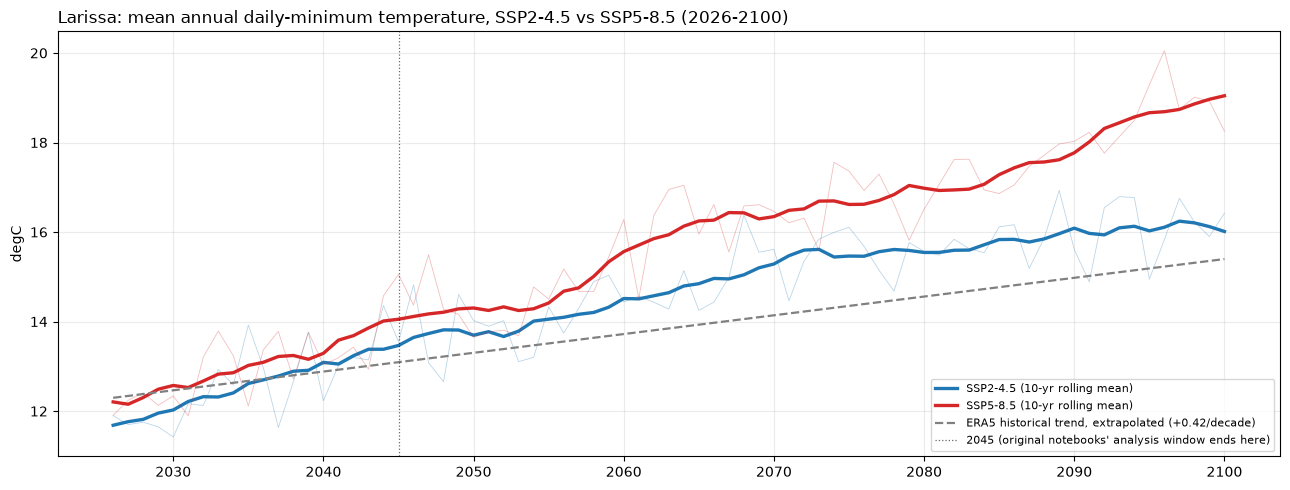

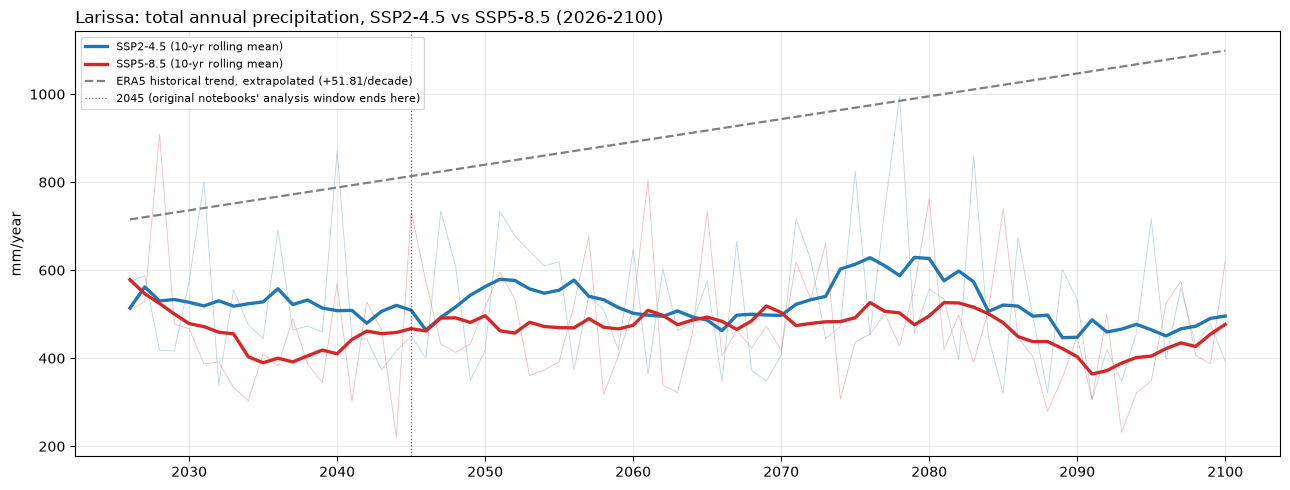

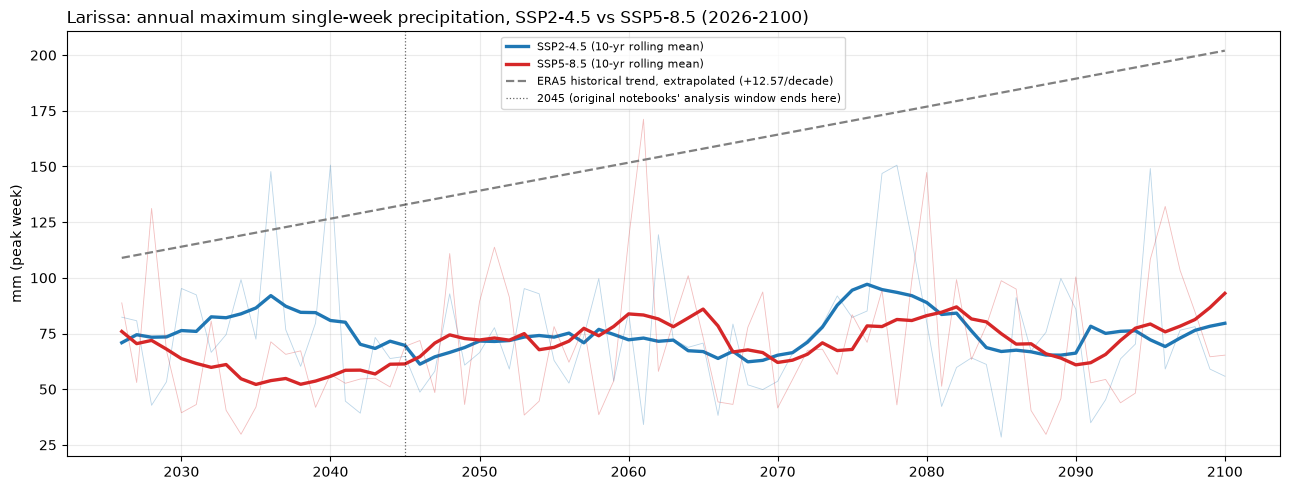

In [4]:
YEARS_FULL = np.arange(2026, 2101)

def era5_trend_extrapolated(series, years):
    y = series.dropna()
    lr = stats.linregress(y.index.values.astype(float), y.values.astype(float))
    return lr.intercept + lr.slope * years, lr

def plot_divergence(indicator, era5_series, ylabel, title, out_name):
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(ann245.index, ann245[indicator], color="tab:blue", lw=0.6, alpha=0.3)
    ax.plot(ann245.index, ann245[indicator].rolling(10, center=True, min_periods=5).mean(),
            color="tab:blue", lw=2.4, label="SSP2-4.5 (10-yr rolling mean)")
    ax.plot(ann585.index, ann585[indicator], color="tab:red", lw=0.6, alpha=0.3)
    ax.plot(ann585.index, ann585[indicator].rolling(10, center=True, min_periods=5).mean(),
            color="tab:red", lw=2.4, label="SSP5-8.5 (10-yr rolling mean)")
    extrap, lr = era5_trend_extrapolated(era5_series, YEARS_FULL)
    ax.plot(YEARS_FULL, extrap, "--", color="gray", lw=1.6,
            label=f"ERA5 historical trend, extrapolated ({lr.slope*10:+.2f}/decade)")
    ax.axvline(2045, color="black", lw=0.9, ls=":", alpha=0.6, label="2045 (original notebooks' analysis window ends here)")
    ax.set_title(title, loc="left"); ax.set_ylabel(ylabel); ax.legend(fontsize=8)
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIG_DIR / out_name, dpi=150)
    plt.show()

plot_divergence("tmin_mean", era5_annual["tmin_mean"], "degC",
                "Larissa: mean annual daily-minimum temperature, SSP2-4.5 vs SSP5-8.5 (2026-2100)",
                "divergence_larissa_tmin_mean.png")
plot_divergence("precip_total", era5_annual["precip_scaled"], "mm/year",
                "Larissa: total annual precipitation, SSP2-4.5 vs SSP5-8.5 (2026-2100)",
                "divergence_larissa_precip_total.png")
plot_divergence("max_week_precip_mm", era5_indicators["max_week_precip_mm"], "mm (peak week)",
                "Larissa: annual maximum single-week precipitation, SSP2-4.5 vs SSP5-8.5 (2026-2100)",
                "divergence_larissa_max_week_precip.png")

## 4. Quantitative divergence test -- decadal bins

Same "is the gap bigger than the noise" test as the Seville notebook: pooled interannual standard
deviation of the two scenarios within each ~10-year period as the noise floor.

In [5]:
BINS = [(2026, 2045), (2046, 2055), (2056, 2065), (2066, 2075),
        (2076, 2085), (2086, 2095), (2096, 2100)]  # first bin matches the original
                                                   # notebooks' own 2026-2045 window

def decadal_compare(indicator):
    rows = []
    for lo, hi in BINS:
        s245 = ann245.loc[lo:hi, indicator]
        s585 = ann585.loc[lo:hi, indicator]
        diff = s585.mean() - s245.mean()
        noise = float(np.sqrt((s245.std() ** 2 + s585.std() ** 2) / 2))
        rows.append({
            "period": f"{lo}-{hi}", "ssp245_mean": s245.mean(), "ssp585_mean": s585.mean(),
            "diff_585_minus_245": diff, "noise_sd": noise,
            "distinguishable": bool(abs(diff) > noise),
        })
    return pd.DataFrame(rows).set_index("period")

tmin_decadal = decadal_compare("tmin_mean")
precip_decadal = decadal_compare("precip_total")
maxweek_decadal = decadal_compare("max_week_precip_mm")

tmin_decadal.to_csv(OUT_DIR / "larissa_divergence_tmin_mean_decadal.csv")
precip_decadal.to_csv(OUT_DIR / "larissa_divergence_precip_total_decadal.csv")
maxweek_decadal.to_csv(OUT_DIR / "larissa_divergence_max_week_precip_decadal.csv")

print("tmin_mean:")
display(tmin_decadal.round(2))
print("\nprecip_total:")
display(precip_decadal.round(1))
print("\nmax_week_precip_mm:")
display(maxweek_decadal.round(1))

tmin_mean:


,ssp245_mean,ssp585_mean,diff_585_minus_245,noise_sd,distinguishable
period,,,,,
2026-2045,12.63,13.06,0.42,0.86,False
2046-2055,13.77,14.25,0.47,0.66,False
2056-2065,14.51,15.71,1.20,0.73,True
2066-2075,15.47,16.49,1.01,0.66,True
2076-2085,15.54,16.93,1.38,0.47,True
2086-2095,15.97,18.01,2.04,0.70,True
2096-2100,16.23,19.00,2.77,0.54,True



precip_total:


,ssp245_mean,ssp585_mean,diff_585_minus_245,noise_sd,distinguishable
period,,,,,
2026-2045,513.7,457.2,-56.5,147.2,False
2046-2055,579.5,462.3,-117.1,115.7,True
2056-2065,497.7,509.0,11.2,142.1,False
2066-2075,522.3,474.1,-48.2,142.4,False
2076-2085,576.0,526.4,-49.6,179.1,False
2086-2095,487.3,364.2,-123.2,118.4,True
2096-2100,451.8,502.6,50.8,87.6,False



max_week_precip_mm:


,ssp245_mean,ssp585_mean,diff_585_minus_245,noise_sd,distinguishable
period,,,,,
2026-2045,78.0,60.0,-18.0,26.2,False
2046-2055,71.4,73.0,1.5,23.3,False
2056-2065,73.0,83.3,10.4,32.2,False
2066-2075,66.4,63.0,-3.4,17.7,False
2076-2085,83.6,84.6,1.0,36.5,False
2086-2095,78.3,61.9,-16.4,30.0,False
2096-2100,65.7,90.0,24.3,21.5,True


## 5. Direct answer: did the signal really start right where the original notebooks stopped (2045)?

In [6]:
for name, table in [("tmin_mean", tmin_decadal), ("precip_total", precip_decadal),
                    ("max_week_precip_mm", maxweek_decadal)]:
    first_distinguishable = table[table["distinguishable"]]
    bin_original = table.loc["2026-2045"]
    print(f"{name}:")
    print(f"  2026-2045 (matches the original notebooks' own window): distinguishable = {bin_original['distinguishable']}, "
          f"diff = {bin_original['diff_585_minus_245']:+.3f}, noise_sd = {bin_original['noise_sd']:.3f}")
    if len(first_distinguishable):
        print(f"  First distinguishable period: {first_distinguishable.index[0]}")
    else:
        print(f"  Never distinguishable within 2026-2100 at this noise threshold")
    print()

tmin_mean:
  2026-2045 (matches the original notebooks' own window): distinguishable = False, diff = +0.423, noise_sd = 0.862
  First distinguishable period: 2056-2065

precip_total:
  2026-2045 (matches the original notebooks' own window): distinguishable = False, diff = -56.510, noise_sd = 147.216
  First distinguishable period: 2046-2055

max_week_precip_mm:
  2026-2045 (matches the original notebooks' own window): distinguishable = False, diff = -17.980, noise_sd = 26.183
  First distinguishable period: 2096-2100



In [7]:
era5_min_spi3 = pd.read_csv("../../Historical/eda_outputs/larissa/larissa_volatility_annual.csv", index_col=0)["min_spi3"]

## 6. `min_spi3` -- drought severity, 2026-2100

Same full-length-plot / decadal-divergence-test treatment as Sections 3-5, applied to Larissa's
drought-depth indicator -- the same one the 2026-2045 EDA notebook flagged as reversing Larissa's
historical flat-to-improving drought story.

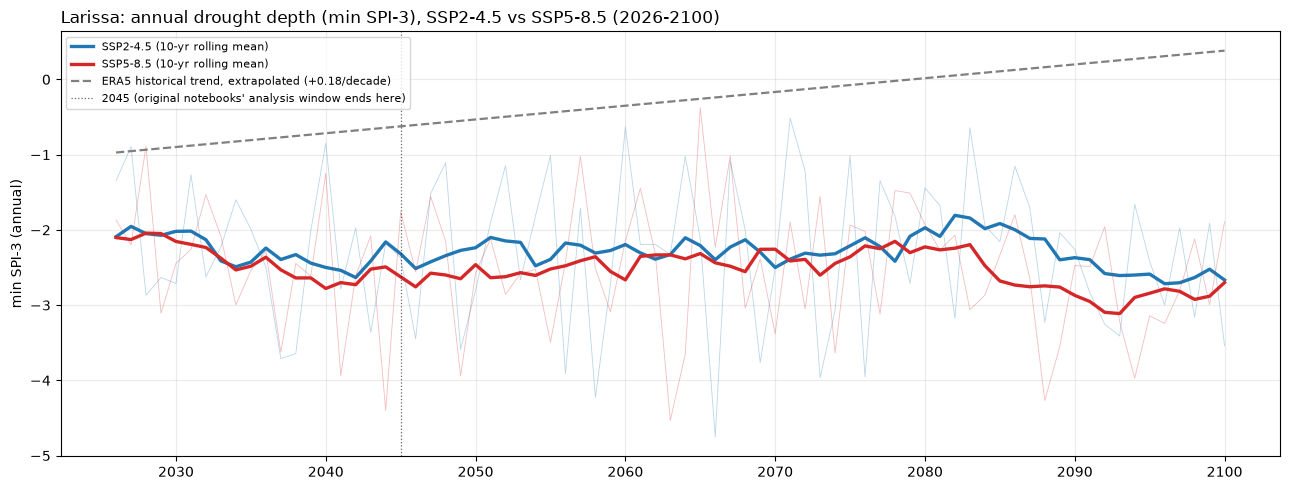

min_spi3:


,ssp245_mean,ssp585_mean,diff_585_minus_245,noise_sd,distinguishable
period,,,,,
2026-2045,-2.28,-2.45,-0.17,0.84,False
2046-2055,-2.10,-2.64,-0.53,0.84,False
2056-2065,-2.31,-2.35,-0.05,1.18,False
2066-2075,-2.39,-2.41,-0.02,1.19,False
2076-2085,-2.09,-2.27,-0.18,0.80,False
2086-2095,-2.40,-2.95,-0.56,0.80,False
2096-2100,-2.72,-2.61,0.11,0.66,False



2026-2045 (matches the original notebooks' own window): distinguishable = False, diff = -0.170, noise_sd = 0.841
Never distinguishable within 2026-2100 at this noise threshold


In [8]:
plot_divergence("min_spi3", era5_min_spi3, "min SPI-3 (annual)",
                "Larissa: annual drought depth (min SPI-3), SSP2-4.5 vs SSP5-8.5 (2026-2100)",
                "divergence_larissa_min_spi3.png")

spi3_decadal = decadal_compare("min_spi3")
spi3_decadal.to_csv(OUT_DIR / "larissa_divergence_min_spi3_decadal.csv")
print("min_spi3:")
display(spi3_decadal.round(2))

bin_original = spi3_decadal.loc["2026-2045"]
first_distinguishable = spi3_decadal[spi3_decadal["distinguishable"]]
print(f"\n2026-2045 (matches the original notebooks' own window): distinguishable = {bin_original['distinguishable']}, "
      f"diff = {bin_original['diff_585_minus_245']:+.3f}, noise_sd = {bin_original['noise_sd']:.3f}")
if len(first_distinguishable):
    print(f"First distinguishable period: {first_distinguishable.index[0]}")
else:
    print("Never distinguishable within 2026-2100 at this noise threshold")

## 7. `rx1day_mm` -- annual maximum single-day precipitation, 2026-2100

The most direct flood-peak indicator available -- a single extreme day, not a weekly aggregate --
and the closest like-for-like comparison to a Storm-Daniel-type event.

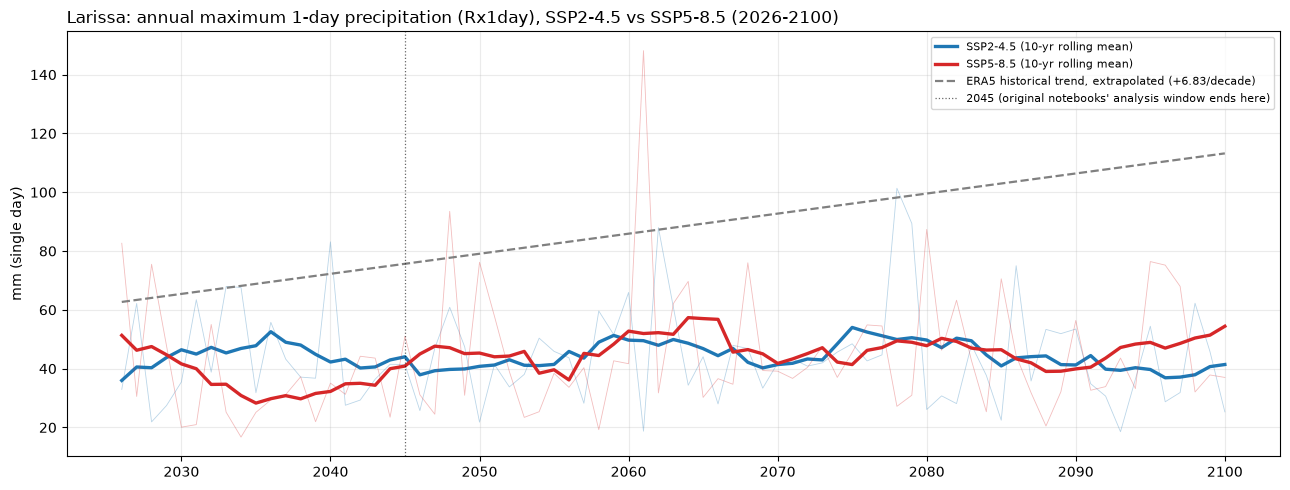

rx1day_mm:


,ssp245_mean,ssp585_mean,diff_585_minus_245,noise_sd,distinguishable
period,,,,,
2026-2045,44.1,37.4,-6.7,17.3,False
2046-2055,41.2,44.0,2.8,19.0,False
2056-2065,49.5,51.9,2.4,29.8,False
2066-2075,41.8,43.3,1.5,9.8,False
2076-2085,47.1,50.3,3.2,23.7,False
2086-2095,44.4,40.5,-3.9,16.0,False
2096-2100,38.8,50.0,11.2,17.8,False



2026-2045 (matches the original notebooks' own window): distinguishable = False, diff = -6.7, noise_sd = 17.3
Never distinguishable within 2026-2100 at this noise threshold


In [9]:
plot_divergence("rx1day_mm", era5_rx1day, "mm (single day)",
                "Larissa: annual maximum 1-day precipitation (Rx1day), SSP2-4.5 vs SSP5-8.5 (2026-2100)",
                "divergence_larissa_rx1day.png")

rx1day_decadal = decadal_compare("rx1day_mm")
rx1day_decadal.to_csv(OUT_DIR / "larissa_divergence_rx1day_decadal.csv")
print("rx1day_mm:")
display(rx1day_decadal.round(1))

bin_original = rx1day_decadal.loc["2026-2045"]
first_distinguishable = rx1day_decadal[rx1day_decadal["distinguishable"]]
print(f"\n2026-2045 (matches the original notebooks' own window): distinguishable = {bin_original['distinguishable']}, "
      f"diff = {bin_original['diff_585_minus_245']:+.1f}, noise_sd = {bin_original['noise_sd']:.1f}")
if len(first_distinguishable):
    print(f"First distinguishable period: {first_distinguishable.index[0]}")
else:
    print("Never distinguishable within 2026-2100 at this noise threshold")

## 8. Heavy-precipitation-day count, 2026-2100

Days/year exceeding the fixed ERA5 1990-2020 P95-of-wet-days threshold (21.65 mm/day) -- frequency
of intense events rather than the single worst day.

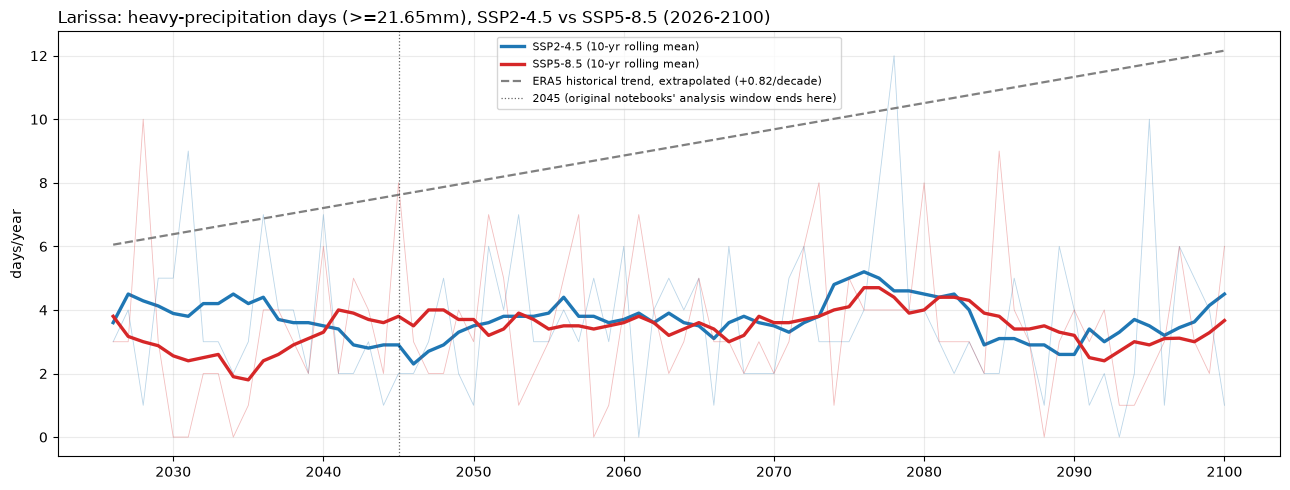

heavy_days:


,ssp245_mean,ssp585_mean,diff_585_minus_245,noise_sd,distinguishable
period,,,,,
2026-2045,3.6,3.2,-0.4,2.35,False
2046-2055,3.6,3.2,-0.4,1.83,False
2056-2065,3.9,3.8,-0.1,2.03,False
2066-2075,3.3,3.6,0.3,1.95,False
2076-2085,4.4,4.4,0.0,2.78,False
2086-2095,3.4,2.5,-0.9,2.34,False
2096-2100,3.4,4.0,0.6,2.10,False



2026-2045 (matches the original notebooks' own window): distinguishable = False, diff = -0.40, noise_sd = 2.35
Never distinguishable within 2026-2100 at this noise threshold


In [10]:
plot_divergence("heavy_days", era5_heavy_days, "days/year",
                "Larissa: heavy-precipitation days (>=21.65mm), SSP2-4.5 vs SSP5-8.5 (2026-2100)",
                "divergence_larissa_heavy_days.png")

heavy_decadal = decadal_compare("heavy_days")
heavy_decadal.to_csv(OUT_DIR / "larissa_divergence_heavy_days_decadal.csv")
print("heavy_days:")
display(heavy_decadal.round(2))

bin_original = heavy_decadal.loc["2026-2045"]
first_distinguishable = heavy_decadal[heavy_decadal["distinguishable"]]
print(f"\n2026-2045 (matches the original notebooks' own window): distinguishable = {bin_original['distinguishable']}, "
      f"diff = {bin_original['diff_585_minus_245']:+.2f}, noise_sd = {bin_original['noise_sd']:.2f}")
if len(first_distinguishable):
    print(f"First distinguishable period: {first_distinguishable.index[0]}")
else:
    print("Never distinguishable within 2026-2100 at this noise threshold")

## 9. SDII (Simple Daily Intensity Index), 2026-2100

Total annual precipitation / wet-day count -- tests whether rainfall becomes less frequent but more
intense per event when it does fall, independent of the total-amount trend already covered in
Section 3.

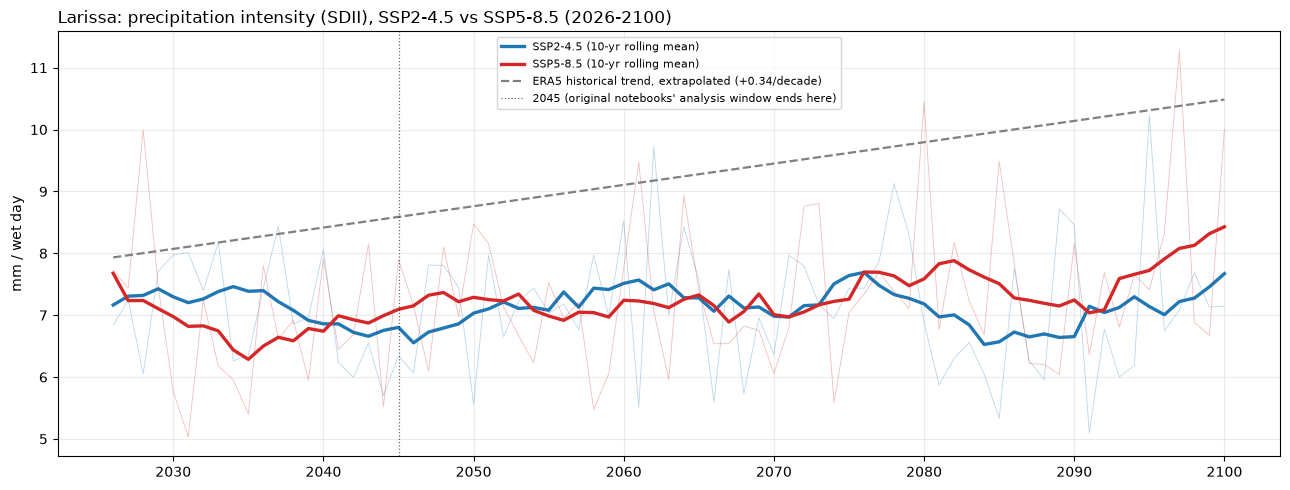

sdii_mm_per_wet_day:


,ssp245_mean,ssp585_mean,diff_585_minus_245,noise_sd,distinguishable
period,,,,,
2026-2045,7.031,6.905,-0.126,1.029,False
2046-2055,7.102,7.252,0.150,0.802,False
2056-2065,7.568,7.229,-0.338,1.215,False
2066-2075,6.970,6.971,0.001,0.946,False
2076-2085,6.972,7.831,0.859,1.208,False
2086-2095,7.144,7.038,-0.106,1.260,False
2096-2100,7.159,8.632,1.474,1.428,True



2026-2045 (matches the original notebooks' own window): distinguishable = False, diff = -0.126, noise_sd = 1.029
First distinguishable period: 2096-2100


In [11]:
plot_divergence("sdii_mm_per_wet_day", era5_sdii, "mm / wet day",
                "Larissa: precipitation intensity (SDII), SSP2-4.5 vs SSP5-8.5 (2026-2100)",
                "divergence_larissa_sdii.png")

sdii_decadal = decadal_compare("sdii_mm_per_wet_day")
sdii_decadal.to_csv(OUT_DIR / "larissa_divergence_sdii_decadal.csv")
print("sdii_mm_per_wet_day:")
display(sdii_decadal.round(3))

bin_original = sdii_decadal.loc["2026-2045"]
first_distinguishable = sdii_decadal[sdii_decadal["distinguishable"]]
print(f"\n2026-2045 (matches the original notebooks' own window): distinguishable = {bin_original['distinguishable']}, "
      f"diff = {bin_original['diff_585_minus_245']:+.3f}, noise_sd = {bin_original['noise_sd']:.3f}")
if len(first_distinguishable):
    print(f"First distinguishable period: {first_distinguishable.index[0]}")
else:
    print("Never distinguishable within 2026-2100 at this noise threshold")

## 10. Key findings

### Temperature (`tmin_mean`): already pointing the right way by 2045, confirmed soon after

**Not distinguishable from noise through the original 2026-2045 window, then distinguishable from
2056-2065 onward, continuously, for the rest of the century.**

| Period | `tmin_mean` diff (SSP5-8.5 minus SSP2-4.5) | Distinguishable? |
|---|---|---|
| **2026-2045** (original window) | **+0.42 degC** | **No -- right sign, not yet enough** |
| 2046-2055 (first decade past 2045) | +0.47 degC | No |
| 2056-2065 | +1.20 degC | Yes -- first distinguishable period |
| 2066-2075 | +1.01 degC | Yes |
| 2076-2085 | +1.38 degC | Yes |
| 2086-2095 | +2.04 degC | Yes |
| 2096-2100 | +2.77 degC | Yes |

**A genuine city-to-city difference worth noting, not just a repeat of Seville's story:** Seville's
`tas_mean`/`tmax_mean` gap is actually backwards (negative) within the original 2026-2045 window,
flipping sign right after; Larissa's `tmin_mean` gap is already the correct sign within that same
window, just too small and noisy to confirm yet. Both cities converge on the same outcome --
statistically distinguishable by 2056-2065, continuing to grow through 2100 -- but they arrive there
by slightly different early paths. Confirming the *separation timing* is identical across two
independent cities and two different early trajectories is a stronger cross-check than if both had
looked identical from the start.

### Precipitation (`precip_total`): noisier than Seville's, no clean pattern

Only two of seven periods cross the noise threshold (2046-2055 and 2086-2095), and they don't form a
trend -- the decades surrounding each are back to "not distinguishable," and the sign of the
difference flips repeatedly across the century (mostly SSP5-8.5 drier, but wetter in 2056-2065 and
2096-2100). This is consistent with -- if anything, noisier than -- Seville's own precipitation
result, reinforcing that a single realization's precipitation signal stays buried in internal
variability for most of this century at city scale.

### Flood-peak intensity (`max_week_precip_mm`): essentially no separation at all

The clearest null result of either city's study: **six of seven periods are not distinguishable**,
and the one that is (2096-2100) is the very last, partial 5-year bin -- not a sustained trend. Given
`max_week_precip_mm` is one of Larissa's three headline indicators (alongside `tmin_mean` and
`precip_total`), this matters directly: **this single-model comparison cannot currently say whether
SSP2-4.5 and SSP5-8.5 produce meaningfully different flood-peak risk for Larissa, at any point
through 2100.** Any flood-risk framing that leans on a scenario contrast for this indicator isn't
supported by this analysis -- the raw/bias-corrected-vs-historical comparison already built in
`larissa_cmip6_projection_eda.ipynb` remains the defensible claim; a *scenario* contrast for this
indicator specifically is not.

### Drought (`min_spi3`): never distinguishable, matching Seville exactly

**Not a single one of the seven periods crosses the noise threshold.** Both scenarios deepen from
around -2.0/-2.2 (2026-2035) toward -2.4 to -3.0 by mid-to-late century, with SSP5-8.5 usually --
not always -- running somewhat drier, but the noise floor (SD ~0.7-1.2 per decade) never falls
below the gap. This is the identical conclusion reached for Seville's `min_spi3` in the companion
notebook: **the drought signal is real relative to history for both scenarios, but this single-run
comparison cannot say SSP5-8.5 makes Larissa's drought distinguishably worse than SSP2-4.5 does, at
any point through 2100.**

### The wet side, in full: `rx1day`, heavy-day count, and SDII all tell the same null story

Extending beyond `precip_total` and `max_week_precip_mm` to three more wet-side indicators doesn't
change the picture -- if anything it reinforces it:

- **`rx1day_mm`** (annual max single-day precipitation): not distinguishable in any of the 7
  periods. Both scenarios hover in the same 35-52mm range throughout, with no consistent SSP5-8.5-
  minus-SSP2-4.5 direction (the sign flips repeatedly).
- **Heavy-day count** (days >=21.65mm/yr, the fixed ERA5 P95 threshold): not distinguishable in any
  decade -- both scenarios sit around 3-4 heavy days/year for the entire century, differences never
  exceeding roughly 1 day against a ~2 day noise floor.
- **SDII** (mm per wet day): not distinguishable in 6 of 7 periods -- the sole exception is the very
  last, partial bin (2096-2100: SSP2-4.5 7.16 vs. SSP5-8.5 8.63 mm/wet-day), a single isolated blip
  at the tail end, not a sustained trend building toward it.

**None of Larissa's five wet-side/drought indicators (`precip_total`, `max_week_precip_mm`,
`rx1day_mm`, heavy-day count, `min_spi3`) shows a scenario-distinguishable signal anywhere in
2026-2100**, and a sixth (SDII) shows one only in the final five years. This is a materially
stronger version of the same finding Seville's companion notebook reached for its own non-heat
indicators (`precip_total`, `min_spi3`, `days_fwi_gt30`) -- **across both cities, only the direct
heat indicators cleanly separate by scenario in this single-realization comparison; every
precipitation-derived indicator, however constructed, stays buried in noise for the entire
21st century.**

### Answering the motivating question directly

**Did the signal really start right where the original notebooks stopped (2045)?** For `tmin_mean`:
yes, in the sense that matters -- the original 2026-2045 window already has the right-signed gap
(+0.42 degC), it just isn't yet distinguishable from noise; confirmation follows within 20 years, at
2056-2065, the same timing found for Seville's heat indicators. That's the real basis for extending
past 2045, mirrored across both cities. For every precipitation-linked indicator (`precip_total`,
`max_week_precip_mm`, `rx1day_mm`, heavy-day count, SDII) and for `min_spi3`: there's no equivalent
turning point anywhere in the record -- six indicators, one consistent null result, all the way to
2100. **If Larissa's wet-side/flood-risk story needs a scenario contrast to make its point, this
single-model comparison cannot currently provide one; the defensible claim is the raw/bias-corrected-
vs-historical comparison already built in `larissa_cmip6_projection_eda.ipynb`, not a
SSP2-4.5-vs-SSP5-8.5 difference.**

### Standing caveat

Same as Seville's: single model (`cmcc_esm2`), single realization (`r1i1p1f1`) per scenario.
Everything above characterizes this one pair of simulations for Larissa specifically. The proposed
follow-up study in `documentation/SSP_Scenario_Uncertainty_Interpretation.md` Section 5 would be
especially informative for `max_week_precip_mm`, given how weak this single-run signal is -- an
ensemble might reveal a real scenario effect this comparison simply can't detect, or might confirm
that flood-peak risk genuinely doesn't differ much between these two pathways at this horizon.